In [ ]:

# 1. Imports

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# 2. Load dataset

csv_path = "/content/drive/MyDrive/Sikkim/sikkim_ls_onehot.csv"
df = pd.read_csv(csv_path)

# Quick sanity check
print(df.shape)
df.head()


# 3. Drop ID columns

df = df.drop(columns=["fid"])


(1222, 32)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns




# # OPTION A: Drop rows with any NaN

# df_clean = df.dropna()

# print("Rows after dropping NaNs:", df_clean.shape[0])


# # OPTION B: Impute NaNs

# df_clean = df.copy()

# # Soil is categorical → use special category
# df_clean["Soil_type"] = df_clean["Soil_type"].fillna(-1)

# # Continuous variables → median imputation
# continuous_cols = df_clean.columns.drop(["Label", "Soil_type"])

# for col in continuous_cols:
#     df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# print("Rows after imputation:", df_clean.shape[0])

In [ ]:

# 5. Feature / label split

X = df.drop(columns=["Label"])
y = df["Label"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())


X shape: (1222, 30)
y distribution:
 Label
1    612
0    610
Name: count, dtype: int64


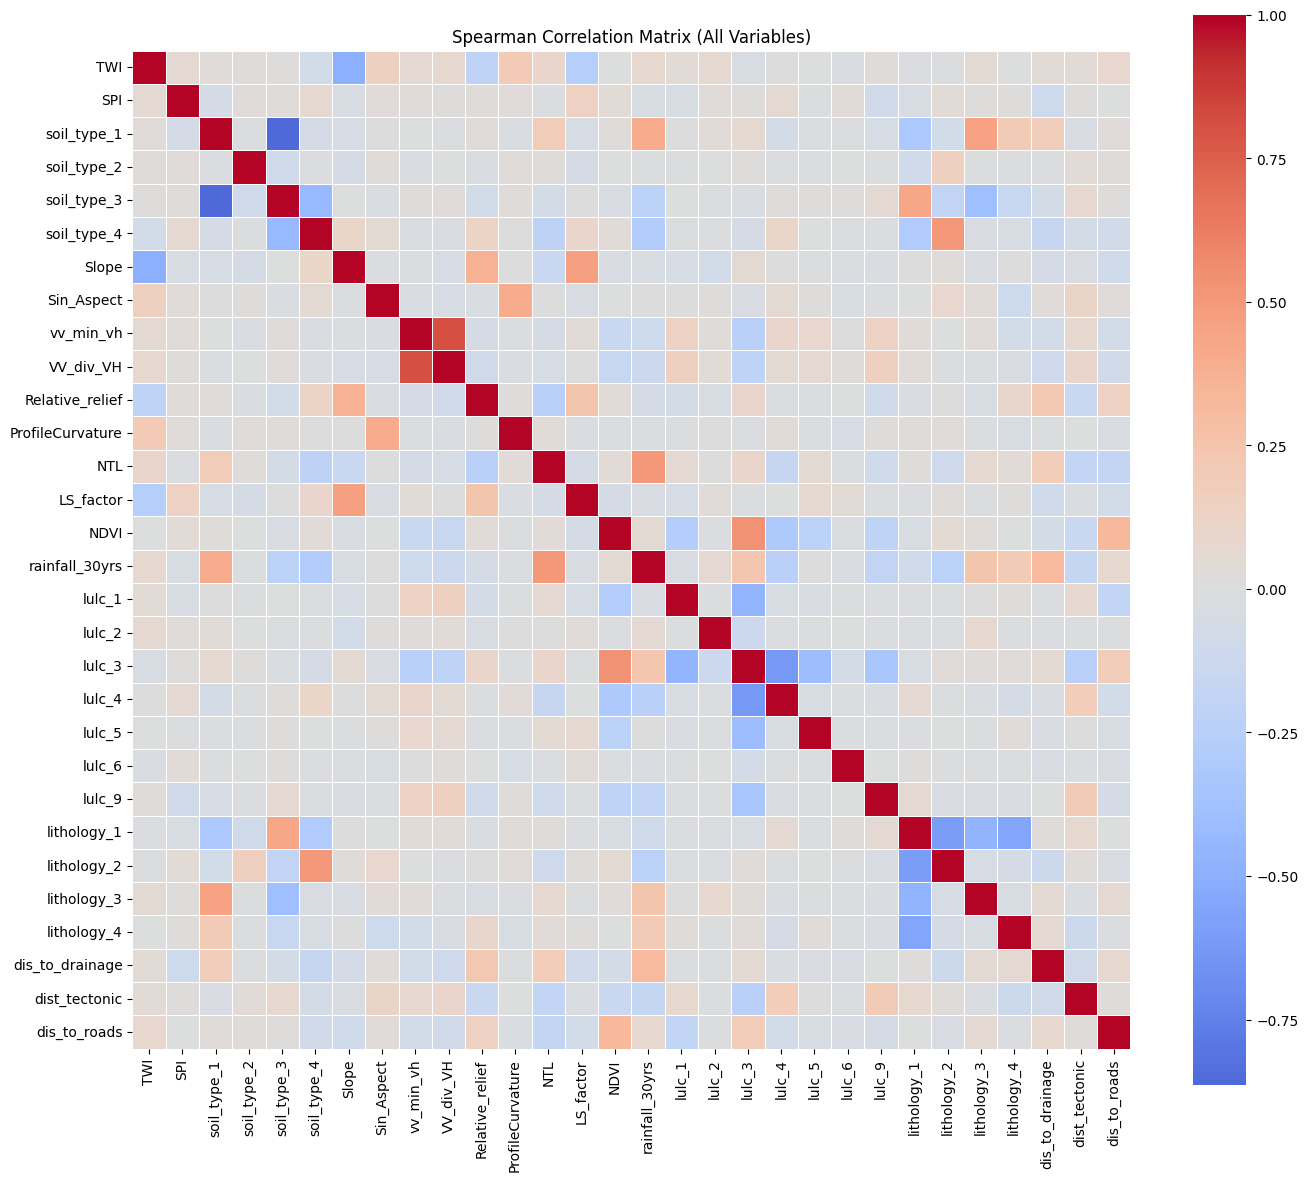

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Initial VIF values:


,Variable,VIF
3,soil_type_2,inf
2,soil_type_1,inf
4,soil_type_3,inf
5,soil_type_4,inf
25,lithology_3,inf
26,lithology_4,inf
22,lulc_9,inf
23,lithology_1,inf
21,lulc_6,inf
20,lulc_5,inf


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'soil_type_2' with VIF = inf


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'lulc_5' with VIF = inf
Dropping 'lithology_1' with VIF = 816.93
Dropping 'soil_type_3' with VIF = 209.34
Dropping 'vv_min_vh' with VIF = 166.59
Dropping 'TWI' with VIF = 58.04
Dropping 'LS_factor' with VIF = 53.38
Dropping 'rainfall_30yrs' with VIF = 42.35
Dropping 'lulc_3' with VIF = 34.28
Dropping 'VV_div_VH' with VIF = 22.34
Dropping 'Relative_relief' with VIF = 12.34

Final variables used for modelling:
['SPI', 'soil_type_1', 'soil_type_4', 'Slope', 'Sin_Aspect', 'ProfileCurvature', 'NTL', 'NDVI', 'lulc_1', 'lulc_2', 'lulc_4', 'lulc_6', 'lulc_9', 'lithology_2', 'lithology_3', 'lithology_4', 'dis_to_drainage', 'dist_tectonic', 'dis_to_roads']


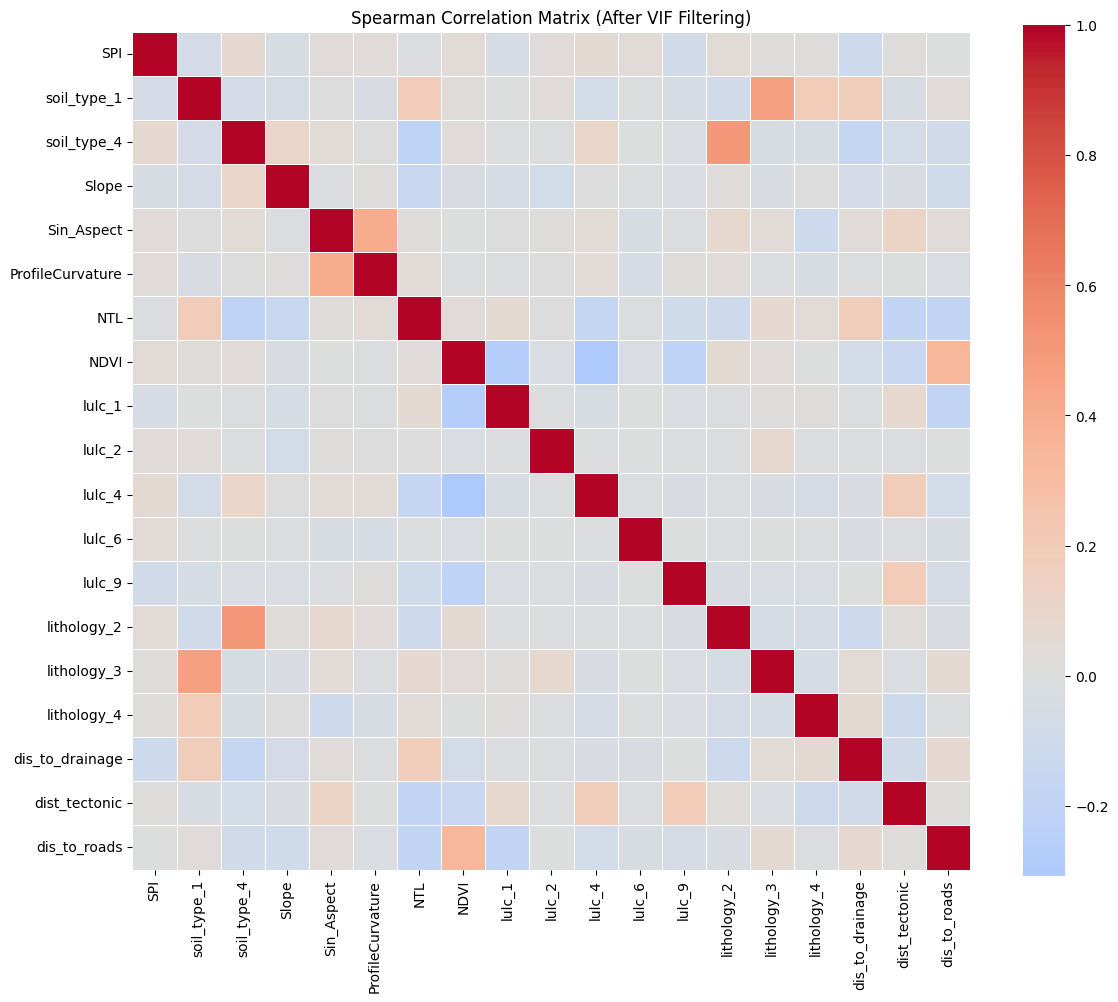

In [ ]:
# ===============================
# 1. Spearman Correlation (Exploratory – allow NaNs)
# ===============================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

corr = X.corr(method="spearman")

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Spearman Correlation Matrix (All Variables)")
plt.tight_layout()
plt.show()


# ===============================
# 2. Prepare data ONLY for VIF
# ===============================

X_vif = X.copy()

# Replace inf with NaN
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN (VIF needs complete cases)
X_vif = X_vif.dropna()

# Drop zero-variance columns
zero_var_cols = X_vif.columns[X_vif.nunique() <= 1]
if len(zero_var_cols) > 0:
    print("Dropping zero-variance columns:", list(zero_var_cols))
    X_vif = X_vif.drop(columns=zero_var_cols)


# ===============================
# 3. VIF computation
# ===============================

def compute_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i)
        for i in range(df.shape[1])
    ]
    return vif_data.sort_values("VIF", ascending=False)


vif_df = compute_vif(X_vif)
print("Initial VIF values:")
display(vif_df)


# ===============================
# 4. Iterative VIF-based feature selection
# ===============================

def vif_feature_selection(df, threshold=10.0):
    df = df.copy()
    while True:
        vif = compute_vif(df)
        max_vif = vif["VIF"].max()

        if max_vif > threshold:
            drop_var = vif.iloc[0]["Variable"]
            print(f"Dropping '{drop_var}' with VIF = {max_vif:.2f}")
            df = df.drop(columns=[drop_var])
        else:
            break
    return df


X_vif_selected = vif_feature_selection(X_vif, threshold=10.0)

# ===============================
# 5. Final feature set for modelling
# ===============================

X_final = X[X_vif_selected.columns].copy()

print("\nFinal variables used for modelling:")
print(X_final.columns.tolist())


# ===============================
# 6. Correlation AFTER VIF (optional, clean)
# ===============================

corr_final = X_final.corr(method="spearman")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_final,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Spearman Correlation Matrix (After VIF Filtering)")
plt.tight_layout()
plt.show()


In [ ]:

# 6. Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
# ===============================
# k-Fold Cross Validation (5 & 10 fold)
# ===============================

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np

# Base XGBoost model for CV (NOT GridSearch model)
xgb_cv_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

def run_xgb_cv(model, X, y, n_splits=5, threshold=0.5, random_state=42):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    f1_scores = []
    auc_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)

        f1_scores.append(f1)
        auc_scores.append(auc)

        print(f"Fold {fold} | F1: {f1:.4f} | AUC: {auc:.4f}")

    print("\nSummary")
    print(f"Mean F1 : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    print(f"Mean AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

    return f1_scores, auc_scores


# ---------- Run 5-Fold CV ----------
print("===== 5-Fold Cross Validation =====")
f1_5, auc_5 = run_xgb_cv(
    model=xgb_cv_model,
    X=X_final,
    y=y,
    n_splits=5,
    threshold=0.5
)

# ---------- Run 10-Fold CV ----------
print("\n===== 10-Fold Cross Validation =====")
f1_10, auc_10 = run_xgb_cv(
    model=xgb_cv_model,
    X=X_final,
    y=y,
    n_splits=10,
    threshold=0.5
)


===== 5-Fold Cross Validation =====
Fold 1 | F1: 0.7848 | AUC: 0.8796
Fold 2 | F1: 0.7615 | AUC: 0.8741
Fold 3 | F1: 0.8264 | AUC: 0.8799
Fold 4 | F1: 0.8049 | AUC: 0.8775
Fold 5 | F1: 0.8270 | AUC: 0.8922

Summary
Mean F1 : 0.8009 ± 0.0251
Mean AUC: 0.8807 ± 0.0062

===== 10-Fold Cross Validation =====
Fold 1 | F1: 0.7840 | AUC: 0.8551
Fold 2 | F1: 0.8525 | AUC: 0.9059
Fold 3 | F1: 0.8067 | AUC: 0.9084
Fold 4 | F1: 0.7586 | AUC: 0.8465
Fold 5 | F1: 0.7805 | AUC: 0.8422
Fold 6 | F1: 0.8067 | AUC: 0.8936
Fold 7 | F1: 0.8130 | AUC: 0.8807
Fold 8 | F1: 0.8099 | AUC: 0.8686
Fold 9 | F1: 0.8136 | AUC: 0.8917
Fold 10 | F1: 0.8475 | AUC: 0.9019

Summary
Mean F1 : 0.8073 ± 0.0271
Mean AUC: 0.8795 ± 0.0236


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.6, 0.8],
    "min_child_weight": [1, 5]
}

grid = GridSearchCV(
    xgb_base,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

xgb = grid.best_estimator_

print("Best XGB parameters:")
print(grid.best_params_)
print("Best CV F1:", grid.best_score_)


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best XGB parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 8, 'min_child_weight': 5, 'n_estimators': 600, 'subsample': 0.8}
Best CV F1: 0.8191013281574883


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       122
           1       0.84      0.83      0.84       123

    accuracy                           0.84       245
   macro avg       0.84      0.84      0.84       245
weighted avg       0.84      0.84      0.84       245

ROC AUC: 0.893509262961482
F1 Score: 0.8360655737704918


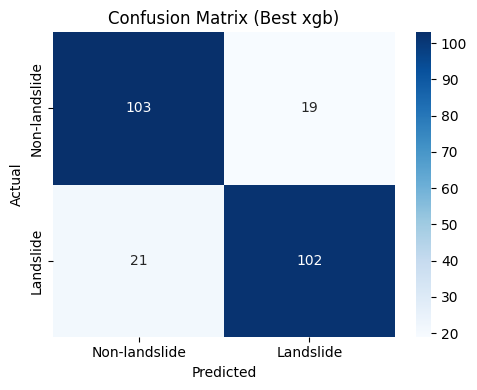

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

# Predictions
y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.54).astype(int)

# Core metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-landslide", "Landslide"],
    yticklabels=["Non-landslide", "Landslide"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Best xgb)")
plt.tight_layout()
plt.show()


In [ ]:
# import numpy as np

# thresholds = np.linspace(0.3, 0.7, 41)
# f1_scores = []

# for t in thresholds:
#     y_t = (y_prob >= t).astype(int)
#     f1_scores.append(f1_score(y_test, y_t))

# best_t = thresholds[np.argmax(f1_scores)]
# print("Best threshold:", best_t)
# print("Best F1:", max(f1_scores))


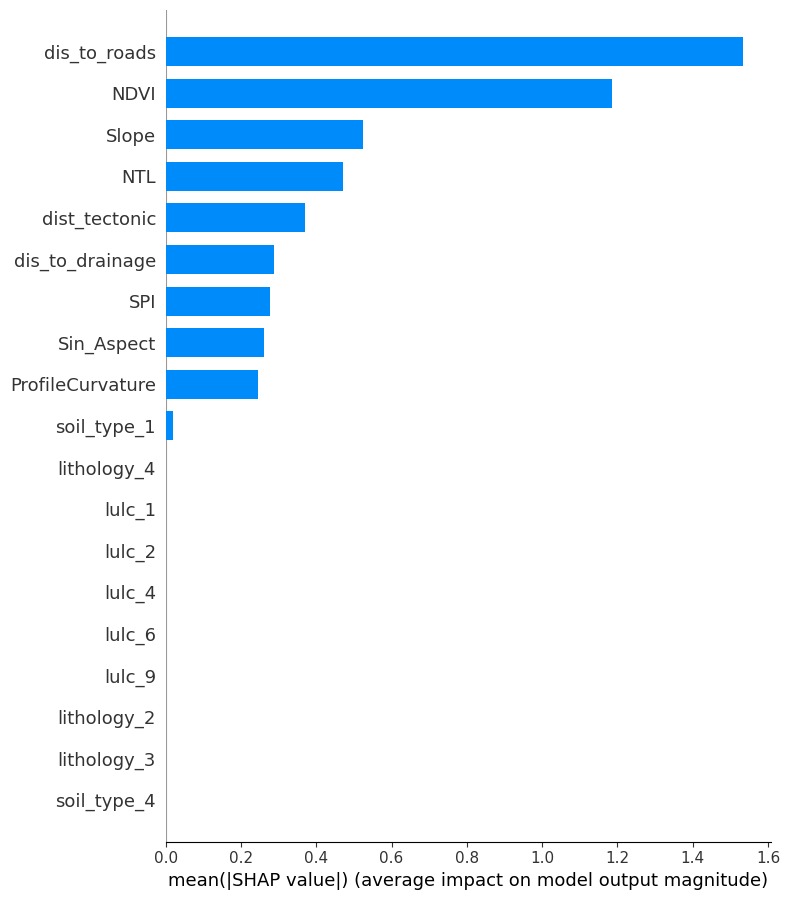

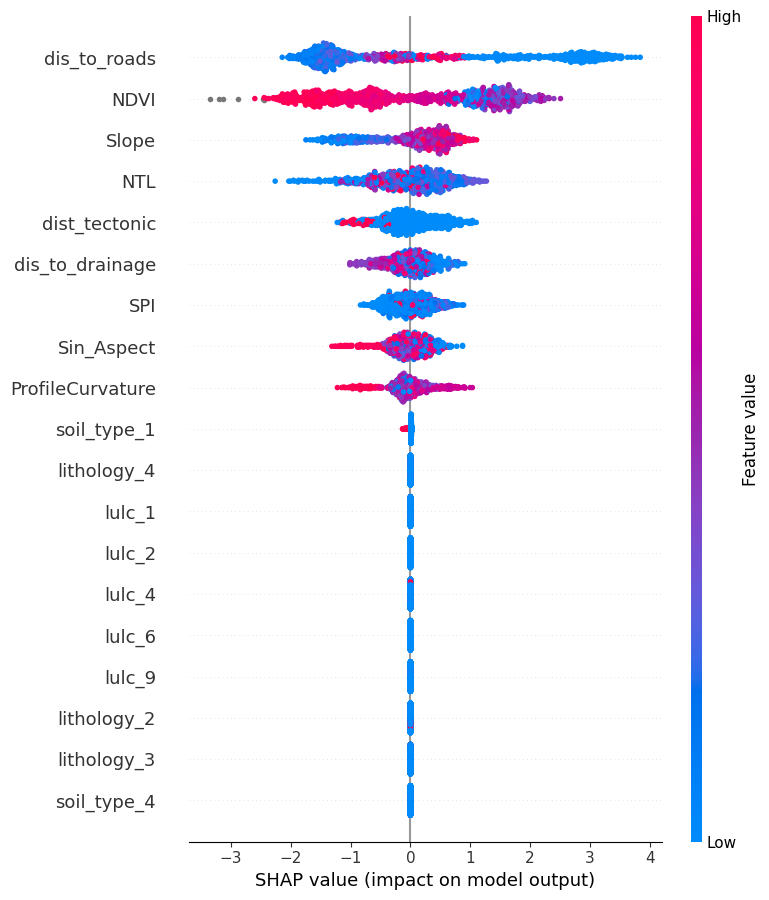

In [ ]:
import shap
import numpy as np

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train)

# -------------------------------
# Handle SHAP output safely
# -------------------------------

# XGBoost binary classifier → 2D array
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
    shap_vals = shap_values

# RandomForest (older behaviour) → list
elif isinstance(shap_values, list):
    shap_vals = shap_values[1]

# RandomForest (newer behaviour) → 3D array
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_vals = shap_values[:, :, 1]

else:
    raise ValueError("Unexpected SHAP output format")

# -------------------------------
# 1. Global feature importance
# -------------------------------
shap.summary_plot(
    shap_vals,
    X_train,
    plot_type="bar",
    max_display=20
)

# -------------------------------
# 2. Global impact + direction
# -------------------------------
shap.summary_plot(
    shap_vals,
    X_train,
    max_display=20
)


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.25, 0.6, 71)
f1_scores = []

for t in thresholds:
    y_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_t))

best_t = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_t)
print("Best F1:", max(f1_scores))


Best threshold: 0.535
Best F1: 0.8360655737704918


In [ ]:
# import joblib
# import os

# save_path = "/content/drive/MyDrive/LSM_models/xgb_model.pkl"

# # Create the directory if it doesn't exist
# os.makedirs(os.path.dirname(save_path), exist_ok=True)

# joblib.dump(
#     xgb,
#     save_path
# )

['/content/drive/MyDrive/LSM_models/xgb_model.pkl']